In [17]:
from pathlib import Path

import librosa
import librosa.display

import matplotlib.pyplot as plt
import numpy as np

import torch

In [18]:
audio_path = Path("../data/fma_small/000/000002.mp3")

print(audio_path.exists())

True


In [19]:
y, sr = librosa.load(audio_path, sr=22050)

print("Waveform shape:", y.shape)
print("Sample rate:", sr)
print("Duration (sec):", len(y) / sr)

Waveform shape: (660984,)
Sample rate: 22050
Duration (sec): 29.976598639455784


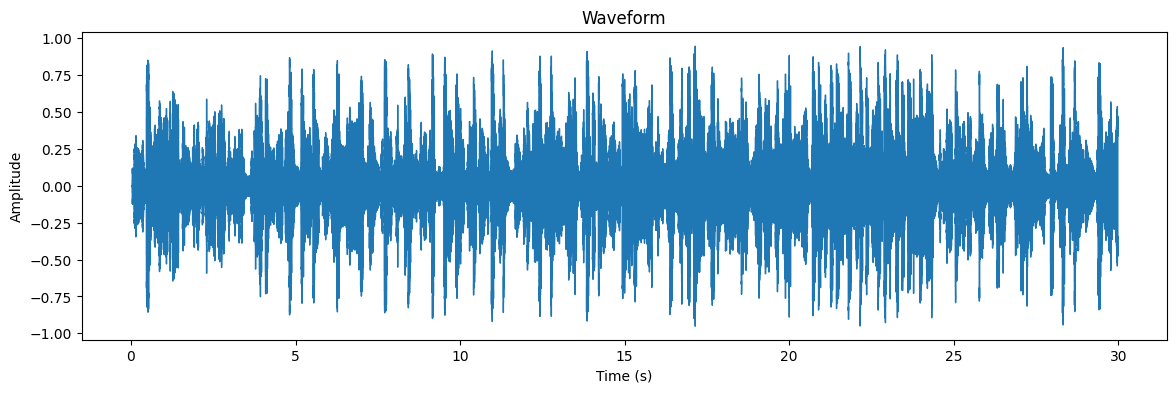

In [20]:
plt.figure(figsize=(14, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.show()

In [21]:
mel = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel, ref=np.max)

print(mel_db.shape)

(128, 1291)


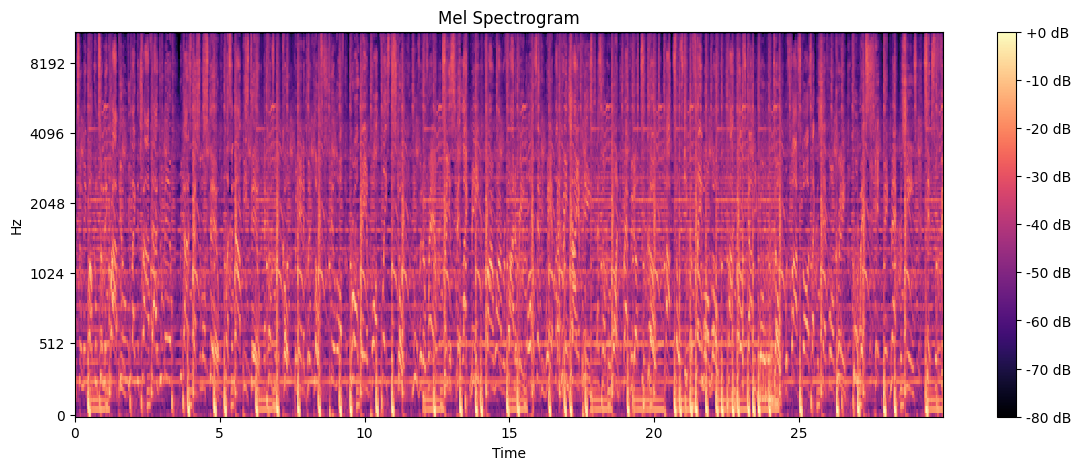

In [22]:
plt.figure(figsize=(14, 5))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Mel Spectrogram")

plt.show()

In [23]:
x = torch.tensor(mel_db)

print(x.shape)

torch.Size([128, 1291])


In [24]:
x_channel = x.unsqueeze(0)

print(x_channel.shape)

torch.Size([1, 128, 1291])


In [25]:
x_batch = x_channel.unsqueeze(0)

print(x_batch.shape)

torch.Size([1, 1, 128, 1291])


In [26]:
import torch.nn as nn

model = nn.Sequential(
    nn.Conv2d(1, 8, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(8, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),

    nn.LazyLinear(128),
    nn.ReLU(),

    nn.Linear(128, 8)
)

In [27]:
out = model(x_batch)

print(out.shape)

torch.Size([1, 8])


In [28]:
target = torch.tensor([3])

print(target.shape)
print(target)

torch.Size([1])
tensor([3])


In [29]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss()

In [30]:
loss = criterion(out, target)

print(loss)

tensor(0.1986, grad_fn=<NllLossBackward0>)


In [31]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01
)

In [32]:
optimizer.zero_grad()

out = model(x_batch)

loss = criterion(out, target)

loss.backward()

optimizer.step()

print(loss.item())

0.19862622022628784


In [33]:
print(model[0].weight[0][0])

tensor([[-0.1066, -0.2889, -0.0757],
        [-0.2104,  0.0362, -0.0214],
        [ 0.2219,  0.1892,  0.0283]], grad_fn=<SelectBackward0>)


In [34]:
import pandas as pd

tracks = pd.read_csv(
    "../data/fma_metadata/tracks.csv",
    header=[0, 1],
    index_col=0
)

tracks.head()

album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

In [35]:
tracks["track"]["genre_top"].value_counts()

genre_top
Rock                   14182
Experimental           10608
Electronic              9372
Hip-Hop                 3552
Folk                    2803
Pop                     2332
Instrumental            2079
International           1389
Classical               1230
Jazz                     571
Old-Time / Historic      554
Spoken                   423
Country                  194
Soul-RnB                 175
Blues                    110
Easy Listening            24
Name: count, dtype: int64

In [36]:
genre_series = tracks["track"]["genre_top"].dropna()

genres = sorted(genre_series.unique())

genre_to_idx = {
    genre: idx
    for idx, genre in enumerate(genres)
}

genre_to_idx

{'Blues': 0,
 'Classical': 1,
 'Country': 2,
 'Easy Listening': 3,
 'Electronic': 4,
 'Experimental': 5,
 'Folk': 6,
 'Hip-Hop': 7,
 'Instrumental': 8,
 'International': 9,
 'Jazz': 10,
 'Old-Time / Historic': 11,
 'Pop': 12,
 'Rock': 13,
 'Soul-RnB': 14,
 'Spoken': 15}

In [37]:
sample = tracks.iloc[0]

track_id = sample.name
genre = sample["track"]["genre_top"]

print(track_id)
print(genre)

2
Hip-Hop


In [38]:
track_str = f"{track_id:06d}"

path = Path(
    "../data/fma_small"
) / track_str[:3] / f"{track_str}.mp3"

print(path)
print(path.exists())

../data/fma_small/000/000002.mp3
True


In [39]:
from pathlib import Path

# Find all tracks that actually exist in fma_small
audio_files = list(
    Path("../data/fma_small").rglob("*.mp3")
)

track_ids = {
    int(file.stem)
    for file in audio_files
}

print(f"Found {len(track_ids)} audio files")

# Filter metadata to only tracks present in fma_small
small_tracks = tracks.loc[
    tracks.index.isin(track_ids)
]

print(f"Found {len(small_tracks)} metadata entries")

# Build genre list
genres = sorted(
    small_tracks["track"]["genre_top"]
    .dropna()
    .unique()
)

genre_to_idx = {
    genre: idx
    for idx, genre in enumerate(genres)
}

idx_to_genre = {
    idx: genre
    for genre, idx in genre_to_idx.items()
}

print("\nGenres:")
for idx, genre in enumerate(genres):
    print(f"{idx}: {genre}")

print("\nGenre counts:")
display(
    small_tracks["track"]["genre_top"]
    .value_counts()
)

Found 8000 audio files
Found 8000 metadata entries

Genres:
0: Electronic
1: Experimental
2: Folk
3: Hip-Hop
4: Instrumental
5: International
6: Pop
7: Rock

Genre counts:


genre_top
Hip-Hop          1000
Pop              1000
Folk             1000
Experimental     1000
Rock             1000
International    1000
Electronic       1000
Instrumental     1000
Name: count, dtype: int64

In [40]:
small_tracks.iloc[0]

album   comments                                                             0
        date_created                                       2008-11-26 01:44:45
        date_released                                      2009-01-05 00:00:00
        engineer                                                           NaN
        favorites                                                            4
        id                                                                   1
        information                                                    <p></p>
        listens                                                           6073
        producer                                                           NaN
        tags                                                                []
        title                                             AWOL - A Way Of Life
        tracks                                                               7
        type                                        

In [41]:
sample = small_tracks.iloc[0]

track_id = sample.name
genre = sample["track"]["genre_top"]

track_str = f"{track_id:06d}"

audio_path = (
    Path("../data/fma_small")
    / track_str[:3]
    / f"{track_str}.mp3"
)

label = genre_to_idx[genre]

y_audio, sr = librosa.load(audio_path, sr=22050)

mel = librosa.feature.melspectrogram(
    y=y_audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(
    mel,
    ref=np.max
)

x = torch.tensor(
    mel_db,
    dtype=torch.float32
).unsqueeze(0)

print("Genre:", genre)
print("Label:", label)
print("Tensor shape:", x.shape)

Genre: Hip-Hop
Label: 3
Tensor shape: torch.Size([1, 128, 1291])


In [42]:
from torch.utils.data import Dataset

In [52]:
class FMADataset(Dataset):
    def __init__(
        self,
        tracks_df,
        genre_to_idx,
        audio_root="../data/fma_small",
        sample_rate=22050,
        n_mels=128,
    ):
        self.tracks = tracks_df
        self.genre_to_idx = genre_to_idx

        self.audio_root = Path(audio_root)
        self.sample_rate = sample_rate
        self.n_mels = n_mels

    def __len__(self):
        return len(self.tracks)

    def __getitem__(self, idx):
        sample = self.tracks.iloc[idx]

        track_id = sample.name
        genre = sample["track"]["genre_top"]

        track_str = f"{track_id:06d}"

        audio_path = (
            self.audio_root
            / track_str[:3]
            / f"{track_str}.mp3"
        )

        y_audio, sr = librosa.load(
            audio_path,
            sr=self.sample_rate,
        )

        mel = librosa.feature.melspectrogram(
            y=y_audio,
            sr=sr,
            n_mels=self.n_mels,
        )

        mel_db = librosa.power_to_db(
            mel,
            ref=np.max,
        )

        x = torch.tensor(
            mel_db,
            dtype=torch.float32,
        ).unsqueeze(0)

        target_frames = 1291

        if x.shape[2] > target_frames:
            x = x[:, :, :target_frames]

        y = torch.tensor(
            self.genre_to_idx[genre],
            dtype=torch.long,
        )

        return x, y

In [53]:
dataset = FMADataset(
    small_tracks,
    genre_to_idx,
)

print(len(dataset))

8000


In [54]:
x, y = dataset[0]

print(x.shape)
print(y)

torch.Size([1, 128, 1291])
tensor(3)


In [55]:
print(idx_to_genre[y.item()])

Hip-Hop


In [56]:
x1, _ = dataset[0]
x2, _ = dataset[1]

print(x1.shape)
print(x2.shape)

torch.Size([1, 128, 1291])
torch.Size([1, 128, 1291])


In [57]:
lengths = []

for i in range(100):
    x, _ = dataset[i]
    lengths.append(x.shape[2])

print(min(lengths))
print(max(lengths))

1291
1291


In [58]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda
